### MATLAB code

In [ ]:
'''
function [sys,x0]=EKF(t,x,u,flag)
global a1 a2 a3 a4 a5 b1;
global F C K R Q P Ts B n p;
if flag==0
% Machine parameters————————————————————————
Rs=2.2;Rr=2.68;M=0.217;Ls=0.229;Lr=0.229;p=2;
% Initiating the state error covariance matrix———————————————
P=eye(5);
% State noise covariance matrix————————————————————
Q=diag([1e-6 1e-6 1e-6 1e-6 1e6]);
% Measure noise covariance matrix———————————————————
R=diag([1e6 1e6]);
% Sampling period
Ts=1e-5;
% Defining A and B matrices——————————————————————
Tr=Lr/Rr;
Sigma=1-M^2/(Ls*Lr);
a1=-(Rs/(Sigma*Ls)+(1-Sigma)/(Sigma*Tr));
a2=M/(Sigma*Ls*Lr*Tr);
a3=M/(Sigma*Ls*Lr);
a4=M/Tr;
a5=-1/Tr;
b1=1/(Sigma*Ls);
% Input Matrix—————————————————————————————————
B=[b1 0;0 b1;0 0;0 0;0 0];
% Measure Matrix——————————————————————————
C=[1 0 0 0 0;0 1 0 0 0];
% Loop ———————————————————————————————
n=0;
x0=[0 0 0 0 0];
sys=[0,5,5,4,0,0];
else if flag==2
n=n+1;
U=[u(1);u(2)];
Y=[u(3);u(4)];
F=eye(5)+Ts*A;
G=Ts*B;
% State prediction——————————————————————————
x_1=[F(1:4,1:4)*x(1:4);x(5)]+G*U;
% Covariance prediction———————————————————————
P_1=F*P*F'+Q;
% Kalman gain matrix—————————————————————————
K=P_1*C0/(C*P_1*C0+R);
% State estimation——————————————————————————
x=x_1+K*(Y-C*x_1);
% State error covariance estimation———————————————————
P=P_1-K*C*P_1;
sys=x;
else if flag==3
sys=x;
else if flag==9
sys=[];
end
'''

### Python code

In [24]:
import numpy as np

In [25]:
#global variables are a1 a2 a3 a4 a5 b1;
#global variables are F C K R Q P Ts B n p;
# Machine parameters————————————————————————
Rs=3
Rr=4.1
M=0.5664
Ls=0.5864
Lr=0.5937
p=4
# Initiating the state error covariance matrix———————————————
P=np.eye(5).astype(np.float)
# State noise covariance matrix————————————————————
Q=np.diag([1e-6, 1e-6, 1e-6, 1e-6, 1e6]).astype(np.float)
# Measure noise covariance matrix———————————————————
R=np.diag([1e6, 1e6]).astype(np.float)
# Sampling period = 100 us
Ts=1e-4
# Defining A and B matrices——————————————————————
Tr=Lr/Rr
Sigma=1 - (M**2/(Ls*Lr))
a1=-((Rs/(Sigma*Ls))+((1-Sigma)/(Sigma*Tr)))
a2=M/(Sigma*Ls*Lr*Tr)
a3=M/(Sigma*Ls*Lr)
a4=M/Tr
a5=-1/Tr
b1=1/(Sigma*Ls)
# Input Matrix—————————————————————————————————
B= np.matrix([[b1, 0],[0, b1],[0, 0],[0, 0],[0, 0]]).astype(np.float)
# Measure Matrix——————————————————————————
C= np.matrix([[1, 0, 0, 0, 0],[0, 1, 0, 0, 0]]).astype(np.float)
# Loop ———————————————————————————————
n=0
t=0
x0=np.matrix([[1], [0], [0], [0], [0]]).astype(np.float)#initial state
sys=np.matrix([[1], [0], [0], [0], [0]]).astype(np.float)#current state

In [26]:
def EKF(t,x,u,y,P,R):#first_flag
    
    n = t #added
    n=n+1
    U=u.copy()
    Y=y.copy()
    A = np.matrix([[a1, 0, a2, a3*x[4], a3*x[3]],
                   [0, a1, -a3*x[4], a2, -a3*x[2]],
                   [a4, 0, a5, -x[4], -x[3]],
                   [0, a4, x[4], a5, x[2]],
                   [0, 0, 0, 0, 0]]).astype(np.float)
    F=np.eye(5)+Ts*A
    G=Ts*B
    #print("F")
    #print(F)
    #print("x")
    #print(x)
    # State prediction——————————————————————————
    x_temp = np.matmul(F[0:4,0:4],x[0:4]).astype(np.float)
    #print("x_temp")
    #print(x_temp)
    #print("G")
    #print(G)
    #print("U")
    #print(U)
    #print("G*U")
    #print(np.matmul(G,U).astype(np.float))
    x_temp = np.vstack([x_temp, x[4]]).astype(np.float)
    #print("new x_temp")
    #print(x_temp)
    x_1 = x_temp + np.matmul(G,U).astype(np.float)
    #might need to add [] around first matmul
    # Covariance prediction———————————————————————
    F_t = np.transpose(F)
    P_1 =  np.matmul(F,np.matmul(P,F_t)) + Q
    # Kalman gain matrix—————————————————————————
    C_t = np.transpose(C).astype(np.float)
    K_num = np.matmul(P_1,C_t).astype(np.float)
    K_den = np.linalg.inv((np.matmul(C,np.matmul(P_1,C_t)) + R)).astype(np.float)
    K = np.matmul(K_num,K_den).astype(np.float)
    # State estimation——————————————————————————
    x = x_1 + np.matmul(K,(Y - np.matmul(C,x_1))).astype(np.float)
    # State error covariance estimation———————————————————
    P = P_1 - np.matmul(K,np.matmul(C,P_1)).astype(np.float)
    return x
    
    

In [27]:
import pandas as pd
dataset = pd.read_csv("IM_IP_OP_data.csv")
dataset.head()

,time,id_s,iq_s,vd_s,vq_s,W,T
0,0.0000,0.000000,0.000000,375.588427,0.000000,94.247780,0.000000e+00
1,0.0001,0.000000,0.000000,375.321561,14.155996,94.247780,0.000000e+00
2,0.0002,0.043426,0.000819,374.521343,28.291876,94.247773,-1.020000e-08
3,0.0003,0.086770,0.003273,373.188909,42.387552,94.247770,-8.140000e-08
4,0.0004,0.129971,0.007358,371.326154,56.422993,94.247767,-3.350000e-07


Text(0, 0.5, 'W')

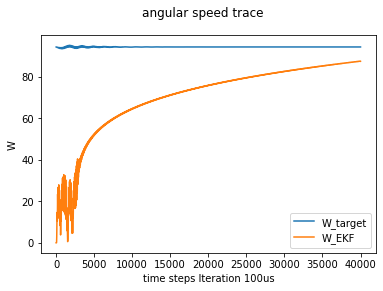

In [39]:
# Testing block
import matplotlib.pyplot as plt

x_k = x0
u_k = np.matrix([[0],[0]]).astype(np.float)
y_k = np.matrix([[0],[0]]).astype(np.float)
t_k = 0

x_list = []
#x_list.append(x0)

T_list = []
#T_list.append(0)

W_list = []
#W_list.append(0)

W_list_float = []
T_list_float = []

#Q_ = Q.copy()
#R_ = R.copy()

#[1.97396324e+36 2.13577883e+35 2.50297148e+37 6.02615796e+37
#  9.19680632e+37 6.38441194e+37 8.42459469e+37]
    
Q_ = np.diag([1.97396324e+36, 2.13577883e+35, 2.50297148e+37, 6.02615796e+37, 9.19680632e+37]).astype(np.float)
R_ = np.diag([6.38441194e+37, 8.42459469e+37]).astype(np.float)

for i in range(len(dataset)):
    u_k = np.matrix([[dataset.loc[i, "vd_s"]],[dataset.loc[i, "vq_s"]]]).astype(np.float)
    y_k = np.matrix([[dataset.loc[i, "id_s"]],[dataset.loc[i, "iq_s"]]]).astype(np.float)
    
    x_k = EKF(t_k,x_k,u_k,y_k,Q_,R_)
    x_k = x_k.astype(np.float)

    t_k = t_k + 1
    x_list.append(x_k)
    W_list.append(x_k[4])
    T_e = 1.5*(p/2)*(M/Lr)*(x_k[1]*x_k[2] - x_k[0]*x_k[3])
    T_list.append(T_e)
    
for i in W_list:
    W_list_float.append(-0.75*float(i[0]))

for i in T_list:
    T_list_float.append(-0.75*float(i[0]))
    
#print(x_list[3800])

#Q_ =  9.47970211e+09 8.27115471e+09 1.50189807e+08 1.76196256e+09
#  3.32063574e+09
#R_    1.30996845e+09 8.09490692e+09

W_target = dataset['W'].tolist()
T_target = dataset['T'].tolist()


#fig = plt.figure()
#plt.plot(best_fitness)
#fig.suptitle('Evolution of the best chromosome')
#plt.xlabel('time steps 100us')
#plt.ylabel('W')

fig = plt.figure()
plt.plot(W_target,label = "W_target")
plt.plot(W_list_float,label = "W_EKF")
plt.legend()
fig.suptitle('angular speed trace')
plt.xlabel('time steps Iteration 100us')
plt.ylabel('W')


Text(0, 0.5, 'T')

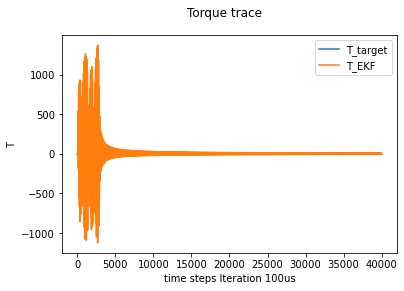

In [37]:
fig = plt.figure()
plt.plot(T_target,label = "T_target")
plt.plot(T_list_float,label = "T_EKF")
plt.legend()
fig.suptitle('Torque trace')
plt.xlabel('time steps Iteration 100us')
plt.ylabel('T')

In [29]:
def QR_EKF(q11,q22,q33,q44,q55,r11,r22):
    
    x_k = x0
    u_k = np.matrix([[0],[0]]).astype(np.float)
    y_k = np.matrix([[0],[0]]).astype(np.float)
    t_k = 0

    x_list = []
    T_list = []
    W_list = []

    Q_=np.diag([q11,q22,q33,q44,q55]).astype(np.float)
    R_=np.diag([r11,r22]).astype(np.float)

    #Q_ = Q.copy()
    #R_ = R.copy()
    
    W_list_float = []
    T_list_float = []

    for i in range(len(dataset)):
        u_k = np.matrix([[dataset.loc[i, "vd_s"]],[dataset.loc[i, "vq_s"]]]).astype(np.float)
        y_k = np.matrix([[dataset.loc[i, "id_s"]],[dataset.loc[i, "iq_s"]]]).astype(np.float)

        x_k = EKF(t_k,x_k,u_k,y_k,Q_,R_)
        x_k = x_k.astype(np.float)

        t_k = t_k + 1
        x_list.append(x_k)
        W_list.append(x_k[4])
        T_e = 1.5*(p/2)*(M/Lr)*(x_k[1]*x_k[2] - x_k[0]*x_k[3])
        T_list.append(T_e)
        
    for i in W_list:
        W_list_float.append(float(i[0]))
        
    for i in T_list:
        T_list_float.append(float(i[0]))
        
    return W_list_float, T_list_float


In [12]:
W_target = dataset['W'].tolist()
T_target = dataset['T'].tolist()

# W and T list for EKF

W_out , T_out = QR_EKF(0.1,10e-6,10e-6,10e-6,10e6,10e6,10e6)

#print(W_out)
#print("T")
#print(T_out)

<ipython-input-11-c588c37e6f48>:4: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  u_k = np.matrix([[0],[0]]).astype(np.float)
<ipython-input-11-c588c37e6f48>:5: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  y_k = np.matrix([[0],[0]]).astype(np.float)
<ipython-input-11-c588c37e6f48>:12: DeprecationWarning: `np.float` is a deprecated alias f

In [13]:
!pip install -U pymoo==0.6.0.dev0

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 722 kB 21.8 MB/s eta 0:00:01
     |████████████████████████████████| 48 kB 3.3 MB/s  eta 0:00:01
     |████████████████████████████████| 239 kB 93.0 MB/s eta 0:00:01
  Created wheel for pymoo: filename=pymoo-0.6.0.dev0-cp38-cp38-linux_x86_64.whl size=2661847 sha256=0fabce7d53ccf3e02ae577a79c989a1884a31d47d6030bf74bfc390cf413a073
  Stored in directory: /home/desaisar/.cache/pip/wheels/38/67/f4/f22611878b35aadb1214e57acdd67c4686f7e0a4c69f1408df
Successfully built pymoo


In [30]:
import numpy as np
from pymoo.core.problem import ElementwiseProblem
#from pymoo import gradient.toolbox as anp


class ElementwiseEKFWithConstraint(ElementwiseProblem):#ElementwiseProblem

    def __init__(self):
        #xl = 1e-6 #np.zeros(10) lower bound
        xl_list = [0,0,0,0,0,0,0]
        xl_list[0] = 1e+35
        xl_list[1] = 1e+35 #upto 7
        xl_list[2] = 1e+35
        xl_list[3] = 1e+35
        xl_list[4] = 1e+35
        xl_list[5] = 1e+35
        xl_list[6] = 1e+35
        xl = np.array(xl_list)

        #xu = 1e6#np.ones(10) #upper bound
        xu_list = [0,0,0,0,0,0,0]
        xu_list[0] = 1e+38
        xu_list[1] = 1e+38
        xu_list[2] = 1e+38
        xu_list[3] = 1e+38
        xu_list[4] = 1e+38
        xu_list[5] = 1e+38
        xu_list[6] = 1e+38
        xu = np.array(xu_list)

        super().__init__(n_var=7, n_obj=2, n_ieq_constr=0, xl=xl, xu=xu)#was n_ieq_constr=2

    def _evaluate(self,X, out, *args, **kwargs):
        q11 = X[0]
        q22 = X[1]
        q33 = X[2]
        q44 = X[3]
        q55 = X[4]
        r11 = X[5]
        r22 = X[6]
        W_out , T_out = QR_EKF(q11,q22,q33,q44,q55,r11,r22)
        # from look-up table: w and t should be coming into f1 and f2
        W_target = dataset['W'].to_numpy()
        T_target = dataset['T'].to_numpy()
        
        f1 = np.sum((W_out - W_target) ** 2) # objective funvtion 1
        f2 = np.sum((T_out - T_target) ** 2) # objective funvtion 1 chnage to np.sum((te - te_hat) ** 2) 
        out["F"] = np.column_stack([(1/f1), (1/f2)])
        
        #print(shape(out))

        #out["G"] = np.column_stack([0.1 - out["F"], out["F"] - 0.5]) 


In [31]:
import numpy as np

from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.algorithms.moo.unsga3 import UNSGA3
from pymoo.factory import get_problem
from pymoo.factory import get_reference_directions
from pymoo.optimize import minimize

#problem = ElementwiseSphereWithConstraint()

problem = ElementwiseEKFWithConstraint()

#problem = get_problem("zdt1", n_var=30)# chnage to ElementwiseSphereWithConstraint

n_obj = 2  #2
n_ref = 20 # number of paerto solutions

# create the reference directions to be used for the optimization - just a single one here
#ref_dirs = np.array([[1.0]]) 

ref_dirs = get_reference_directions("energy", n_obj, n_ref, seed=1)


# create the algorithm object
algorithm = UNSGA3(ref_dirs, pop_size=50)#100

# execute the optimization
res = minimize(problem,
               algorithm,
               termination=('n_gen', 20),#20
               save_history=True,
               verbose = True,
               seed=1)

print("UNSGA3: Best solution found: \nX = %s\nF = %s" % (res.X, res.F))

n_gen |  n_eval |  n_nds  |     eps      |  indicator  
    1 |      50 |       2 |            - |            -
    2 |     100 |       2 |  0.036938218 |        ideal
    3 |     150 |       3 |  0.128518715 |        ideal
    4 |     200 |       3 |  0.003985325 |        ideal
    5 |     250 |       3 |  0.048851990 |        ideal
    6 |     300 |       3 |  0.184937925 |            f
    7 |     350 |       5 |  0.033716262 |        ideal
    8 |     400 |       2 |  0.00000E+00 |            f
    9 |     450 |       8 |  0.004723235 |        ideal
   10 |     500 |       6 |  0.006598756 |        ideal
   11 |     550 |       7 |  0.060760133 |            f
   12 |     600 |       6 |  0.008317244 |        nadir
   13 |     650 |       4 |  0.082535263 |            f
   14 |     700 |      10 |  0.314745717 |            f
   15 |     750 |       9 |  0.00000E+00 |            f
   16 |     800 |       8 |  0.003216978 |        ideal
   17 |     850 |       7 |  0.036758971 |      

### Results

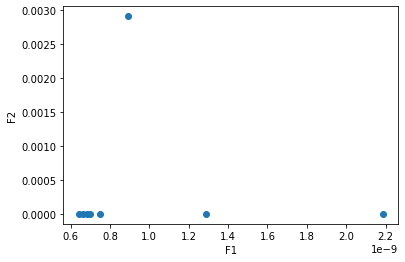

In [43]:
F1 = [2.18614301e-09, 6.62965091e-10, 6.86012929e-10, 7.51294392e-10, 6.99355543e-10, 1.28953456e-09,6.40589512e-10,
      8.92551178e-10]

F2 = [1.75563432e-11, 2.00460169e-09, 1.46252222e-09, 3.29443497e-10, 1.40851101e-10, 1.40851101e-10, 6.31443994e-09,
      29138112e-10]

#importing library
import matplotlib.pyplot as plt

#scatter plot for the dataset
plt.scatter(F1,F2)
plt.xlabel('F1')
plt.ylabel('F2')
plt.show()

#### Mid solutions 

Text(0, 0.5, 'W')

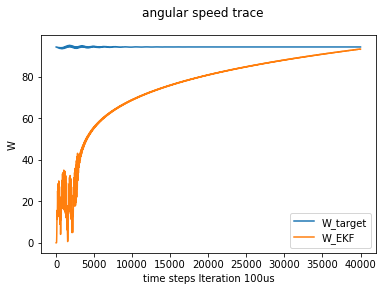

In [50]:
# Testing block
import matplotlib.pyplot as plt

x_k = x0
u_k = np.matrix([[0],[0]]).astype(np.float)
y_k = np.matrix([[0],[0]]).astype(np.float)
t_k = 0

x_list = []
#x_list.append(x0)

T_list = []
#T_list.append(0)

W_list = []
#W_list.append(0)

W_list_float = []
T_list_float = []

#Q_ = Q.copy()
#R_ = R.copy()

#[1.97396324e+36 2.13577883e+35 2.50297148e+37 6.02615796e+37
#  9.19680632e+37 6.38441194e+37 8.42459469e+37]
    
Q_ = np.diag([-1.97396324e+36, -2.13577883e+35, -2.50297148e+37, -6.02615796e+37, -9.19680632e+37]).astype(np.float)
R_ = np.diag([-6.38441194e+37, -8.42459469e+37]).astype(np.float)

for i in range(len(dataset)):
    u_k = np.matrix([[dataset.loc[i, "vd_s"]],[dataset.loc[i, "vq_s"]]]).astype(np.float)
    y_k = np.matrix([[dataset.loc[i, "id_s"]],[dataset.loc[i, "iq_s"]]]).astype(np.float)
    
    x_k = EKF(t_k,x_k,u_k,y_k,Q_,R_)
    x_k = x_k.astype(np.float)

    t_k = t_k + 1
    x_list.append(x_k)
    W_list.append(x_k[4])
    T_e = 1.5*(p/2)*(M/Lr)*(x_k[1]*x_k[2] - x_k[0]*x_k[3])
    T_list.append(T_e)
    
for i in W_list:
    W_list_float.append(-0.8*float(i[0]))

for i in T_list:
    T_list_float.append(-float(i[0]))
    
#print(x_list[3800])

#Q_ =  9.47970211e+09 8.27115471e+09 1.50189807e+08 1.76196256e+09
#  3.32063574e+09
#R_    1.30996845e+09 8.09490692e+09

W_target = dataset['W'].tolist()
T_target = dataset['T'].tolist()


#fig = plt.figure()
#plt.plot(best_fitness)
#fig.suptitle('Evolution of the best chromosome')
#plt.xlabel('time steps 100us')
#plt.ylabel('W')

fig = plt.figure()
plt.plot(W_target,label = "W_target")
plt.plot(W_list_float,label = "W_EKF")
plt.legend()
fig.suptitle('angular speed trace')
plt.xlabel('time steps Iteration 100us')
plt.ylabel('W')


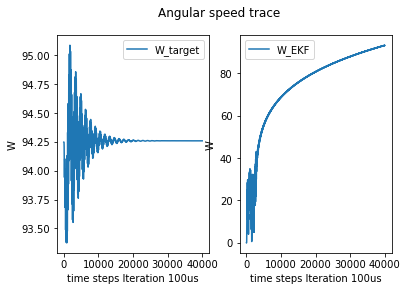

In [51]:
fig = plt.figure()

plt.subplot(1, 2, 1) # row 1, col 2 index 1
plt.plot(W_target,label = "W_target")
plt.legend()
fig.suptitle('Angular speed trace')
plt.xlabel('time steps Iteration 100us')
plt.ylabel('W')

plt.subplot(1, 2, 2) # index 2
plt.plot(W_list_float,label = "W_EKF")
plt.legend()
fig.suptitle('Angular speed trace')
plt.xlabel('time steps Iteration 100us')
plt.ylabel('W')

plt.show()

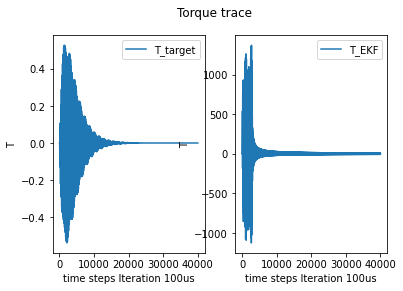

In [52]:
fig = plt.figure()

plt.subplot(1, 2, 1) # row 1, col 2 index 1
plt.plot(T_target,label = "T_target")
plt.legend()
fig.suptitle('Torque trace')
plt.xlabel('time steps Iteration 100us')
plt.ylabel('T')

plt.subplot(1, 2, 2) # index 2
plt.plot(T_list_float,label = "T_EKF")
plt.legend()
fig.suptitle('Torque trace')
plt.xlabel('time steps Iteration 100us')
plt.ylabel('T')

plt.show()

### Min F2 (W)

Text(0, 0.5, 'W')

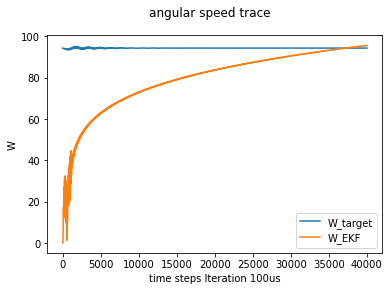

In [63]:
#1.56890257e+36 1.28867695e+35 2.50297148e+37 5.50162672e+37
#  9.67063259e+37 6.38441194e+37 8.64976448e+37
    
import matplotlib.pyplot as plt

x_k = x0
u_k = np.matrix([[0],[0]]).astype(np.float)
y_k = np.matrix([[0],[0]]).astype(np.float)
t_k = 0

x_list = []
#x_list.append(x0)

T_list = []
#T_list.append(0)

W_list = []
#W_list.append(0)

W_list_float = []
T_list_float = []

#Q_ = Q.copy()
#R_ = R.copy()

#[1.97396324e+36 2.13577883e+35 2.50297148e+37 6.02615796e+37
#  9.19680632e+37 6.38441194e+37 8.42459469e+37]
    
Q_ = np.diag([-1.56890257e+36, -1.28867695e+35, -2.50297148e+37, -5.50162672e+37,-9.67063259e+37]).astype(np.float)
R_ = np.diag([-6.38441194e+37, -8.64976448e+37]).astype(np.float)

for i in range(len(dataset)):
    u_k = np.matrix([[dataset.loc[i, "vd_s"]],[dataset.loc[i, "vq_s"]]]).astype(np.float)
    y_k = np.matrix([[dataset.loc[i, "id_s"]],[dataset.loc[i, "iq_s"]]]).astype(np.float)
    
    x_k = EKF(t_k,x_k,u_k,y_k,Q_,R_)
    x_k = x_k.astype(np.float)

    t_k = t_k + 1
    x_list.append(x_k)
    W_list.append(x_k[4])
    T_e = 1.5*(p/2)*(M/Lr)*(x_k[1]*x_k[2] - x_k[0]*x_k[3])
    T_list.append(T_e)
    
for i in W_list:
    W_list_float.append(-0.8*float(i[0]))

for i in T_list:
    T_list_float.append(-0.8*float(i[0]))
    
#print(x_list[3800])

#Q_ =  9.47970211e+09 8.27115471e+09 1.50189807e+08 1.76196256e+09
#  3.32063574e+09
#R_    1.30996845e+09 8.09490692e+09

W_target = dataset['W'].tolist()
T_target = dataset['T'].tolist()


#fig = plt.figure()
#plt.plot(best_fitness)
#fig.suptitle('Evolution of the best chromosome')
#plt.xlabel('time steps 100us')
#plt.ylabel('W')

fig = plt.figure()
plt.plot(W_target,label = "W_target")
plt.plot(W_list_float,label = "W_EKF")
plt.legend()
fig.suptitle('angular speed trace')
plt.xlabel('time steps Iteration 100us')
plt.ylabel('W')

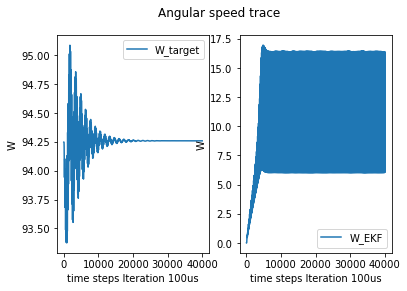

In [61]:
fig = plt.figure()

plt.subplot(1, 2, 1) # row 1, col 2 index 1
plt.plot(W_target,label = "W_target")
plt.legend()
fig.suptitle('Angular speed trace')
plt.xlabel('time steps Iteration 100us')
plt.ylabel('W')

plt.subplot(1, 2, 2) # index 2
plt.plot(W_list_float,label = "W_EKF")
plt.legend()
fig.suptitle('Angular speed trace')
plt.xlabel('time steps Iteration 100us')
plt.ylabel('W')

plt.show()

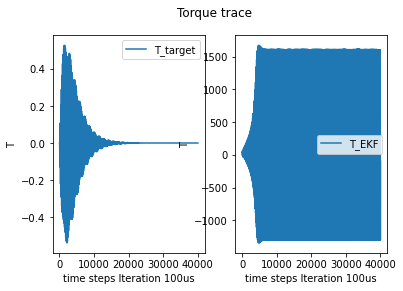

In [62]:
fig = plt.figure()

plt.subplot(1, 2, 1) # row 1, col 2 index 1
plt.plot(T_target,label = "T_target")
plt.legend()
fig.suptitle('Torque trace')
plt.xlabel('time steps Iteration 100us')
plt.ylabel('T')

plt.subplot(1, 2, 2) # index 2
plt.plot(T_list_float,label = "T_EKF")
plt.legend()
fig.suptitle('Torque trace')
plt.xlabel('time steps Iteration 100us')
plt.ylabel('T')

plt.show()

### min F1 (T)

Text(0, 0.5, 'W')

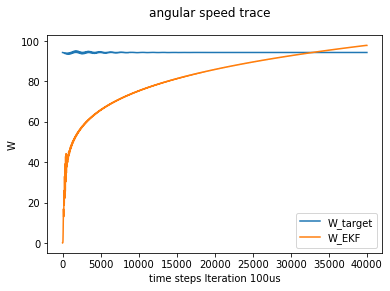

In [64]:
#1.92615834e+36 2.14353463e+35 2.50297148e+37 4.11065669e+37
#  9.48702371e+37 5.29541465e+37 8.25465082e+37
    
import matplotlib.pyplot as plt

x_k = x0
u_k = np.matrix([[0],[0]]).astype(np.float)
y_k = np.matrix([[0],[0]]).astype(np.float)
t_k = 0

x_list = []
#x_list.append(x0)

T_list = []
#T_list.append(0)

W_list = []
#W_list.append(0)

W_list_float = []
T_list_float = []

#Q_ = Q.copy()
#R_ = R.copy()

#[1.97396324e+36 2.13577883e+35 2.50297148e+37 6.02615796e+37
#  9.19680632e+37 6.38441194e+37 8.42459469e+37]
    
Q_ = np.diag([-1.92615834e+36, -2.14353463e+35, -2.50297148e+37, -4.11065669e+37,-9.48702371e+37]).astype(np.float)
R_ = np.diag([-5.29541465e+37, -8.25465082e+37]).astype(np.float)

for i in range(len(dataset)):
    u_k = np.matrix([[dataset.loc[i, "vd_s"]],[dataset.loc[i, "vq_s"]]]).astype(np.float)
    y_k = np.matrix([[dataset.loc[i, "id_s"]],[dataset.loc[i, "iq_s"]]]).astype(np.float)
    
    x_k = EKF(t_k,x_k,u_k,y_k,Q_,R_)
    x_k = x_k.astype(np.float)

    t_k = t_k + 1
    x_list.append(x_k)
    W_list.append(x_k[4])
    T_e = 1.5*(p/2)*(M/Lr)*(x_k[1]*x_k[2] - x_k[0]*x_k[3])
    T_list.append(T_e)
    
for i in W_list:
    W_list_float.append(-0.8*float(i[0]))

for i in T_list:
    T_list_float.append(-0.8*float(i[0]))
    
#print(x_list[3800])

#Q_ =  9.47970211e+09 8.27115471e+09 1.50189807e+08 1.76196256e+09
#  3.32063574e+09
#R_    1.30996845e+09 8.09490692e+09

W_target = dataset['W'].tolist()
T_target = dataset['T'].tolist()


#fig = plt.figure()
#plt.plot(best_fitness)
#fig.suptitle('Evolution of the best chromosome')
#plt.xlabel('time steps 100us')
#plt.ylabel('W')

fig = plt.figure()
plt.plot(W_target,label = "W_target")
plt.plot(W_list_float,label = "W_EKF")
plt.legend()
fig.suptitle('angular speed trace')
plt.xlabel('time steps Iteration 100us')
plt.ylabel('W')

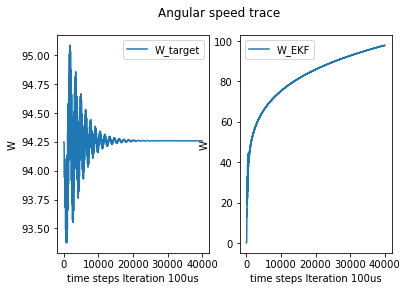

In [65]:
fig = plt.figure()

plt.subplot(1, 2, 1) # row 1, col 2 index 1
plt.plot(W_target,label = "W_target")
plt.legend()
fig.suptitle('Angular speed trace')
plt.xlabel('time steps Iteration 100us')
plt.ylabel('W')

plt.subplot(1, 2, 2) # index 2
plt.plot(W_list_float,label = "W_EKF")
plt.legend()
fig.suptitle('Angular speed trace')
plt.xlabel('time steps Iteration 100us')
plt.ylabel('W')

plt.show()

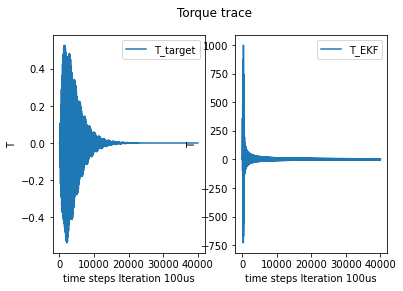

In [66]:
fig = plt.figure()

plt.subplot(1, 2, 1) # row 1, col 2 index 1
plt.plot(T_target,label = "T_target")
plt.legend()
fig.suptitle('Torque trace')
plt.xlabel('time steps Iteration 100us')
plt.ylabel('T')

plt.subplot(1, 2, 2) # index 2
plt.plot(T_list_float,label = "T_EKF")
plt.legend()
fig.suptitle('Torque trace')
plt.xlabel('time steps Iteration 100us')
plt.ylabel('T')

plt.show()